## Modelos Não Supervisionados

## Modelo K-Means

K = nº de clusters a serem encontrados.
O K-Means é um dos algoritmos mais conhecidos de aprendizado de máquina não supervisionado (Unsupervised Learning). Sua principal função é agrupar dados semelhantes em grupos (clusters), sem que exista uma classificação prévia.
Imagine que você possui milhares de clientes e deseja descobrir perfis de consumo. Em vez de criar regras manualmente, o K-Means encontra padrões e forma grupos automaticamente.

    - Como o K-Means funciona?
        A ideia é simples:

        Dados semelhantes ficam no mesmo grupo, enquanto dados diferentes ficam em grupos distintos.

        O algoritmo faz isso medindo a distância entre os pontos (normalmente utilizando a distância euclidiana).

Resumo
O K-Means pode ser resumido em cinco etapas:
Definir o número de grupos (K).
Escolher centróides iniciais.
Atribuir cada ponto ao centróide mais próximo.
Recalcular os centróides como a média dos pontos de cada grupo.
Repetir os passos 3 e 4 até que os grupos se estabilizem.
Em essência, o algoritmo busca particionar os dados em grupos internamente homogêneos e externamente distintos, minimizando a distância entre cada ponto e o centróide do seu respectivo cluster. Por sua simplicidade, eficiência e interpretabilidade, ele é um dos algoritmos de clusterização mais utilizados em ciência de dados eaprendizado de máquina.

### Exemplo K-Means

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification

In [2]:
data = make_blobs(
    n_samples= 300,
    n_features= 3,
    centers=4,
    cluster_std=[2,1,1,2],
    random_state=101
)

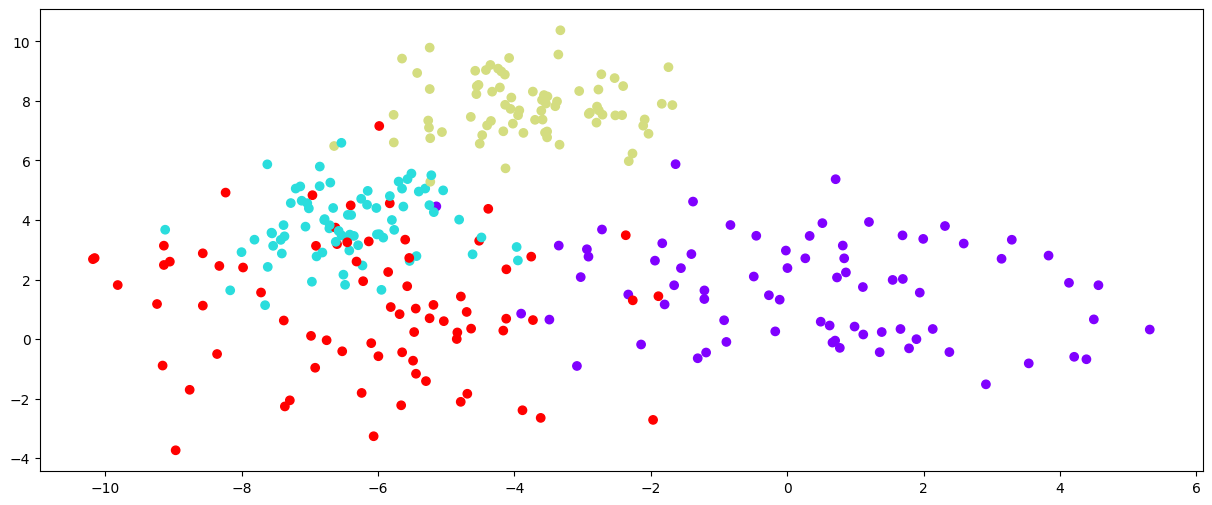

In [4]:
fig, ax = plt.subplots(figsize=(15,6))
plt.scatter(
    data[0][:,0],
    data[0][:,1],
    c= data[1],
    cmap= 'rainbow',
)

In [5]:
from sklearn.cluster import KMeans

In [6]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(data[0])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 3)",

In [7]:
kmeans.cluster_centers_

array([[-5.1037529 ,  5.82641481,  5.49834249],
       [-5.40458471, -0.4244233 , -4.52907813],
       [ 0.39794323,  1.70869799, -9.49056892],
       [-6.7714932 ,  2.35520431, -1.77998738]])

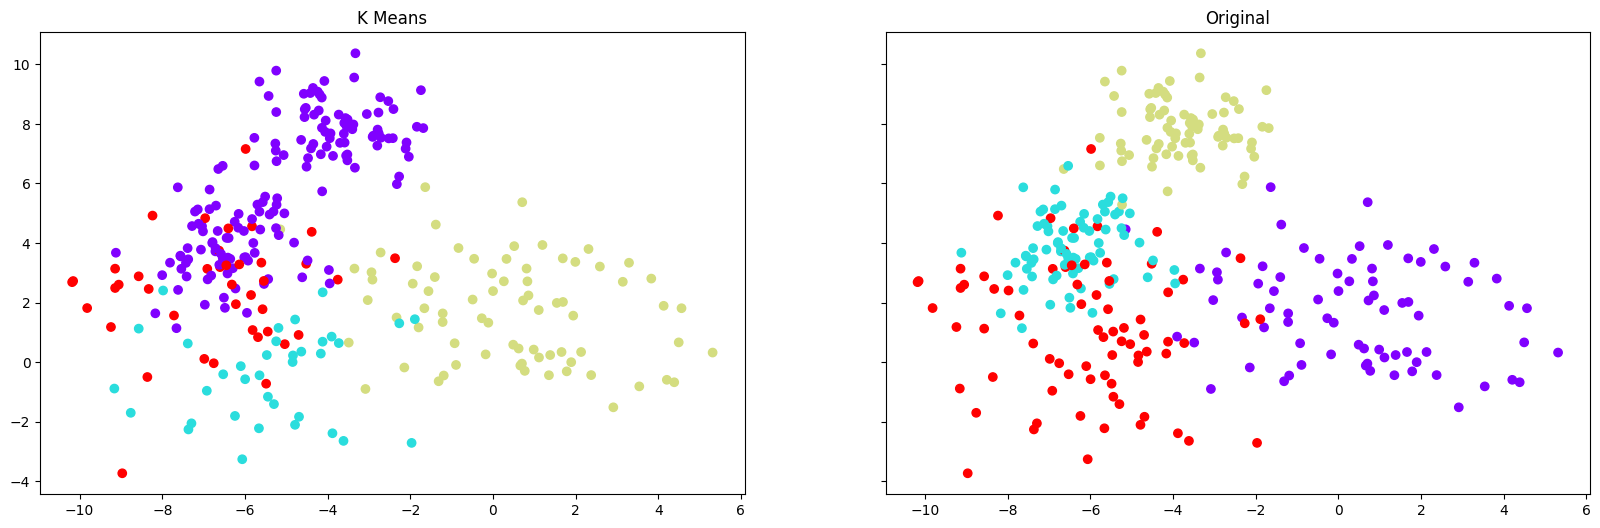

In [11]:
f, (ax1, ax2) = plt.subplots(1,2, sharey=True, figsize=(20,6))
ax1.set_title('K Means')
ax1.scatter(
    data[0][:,0],
    data[0][:,1],
    c= kmeans.labels_,
    cmap = 'rainbow',
)

ax2.set_title('Original')
ax2.scatter(
    data[0][:,0],
    data[0][:,1],
    c= data[1],
    cmap='rainbow',
)

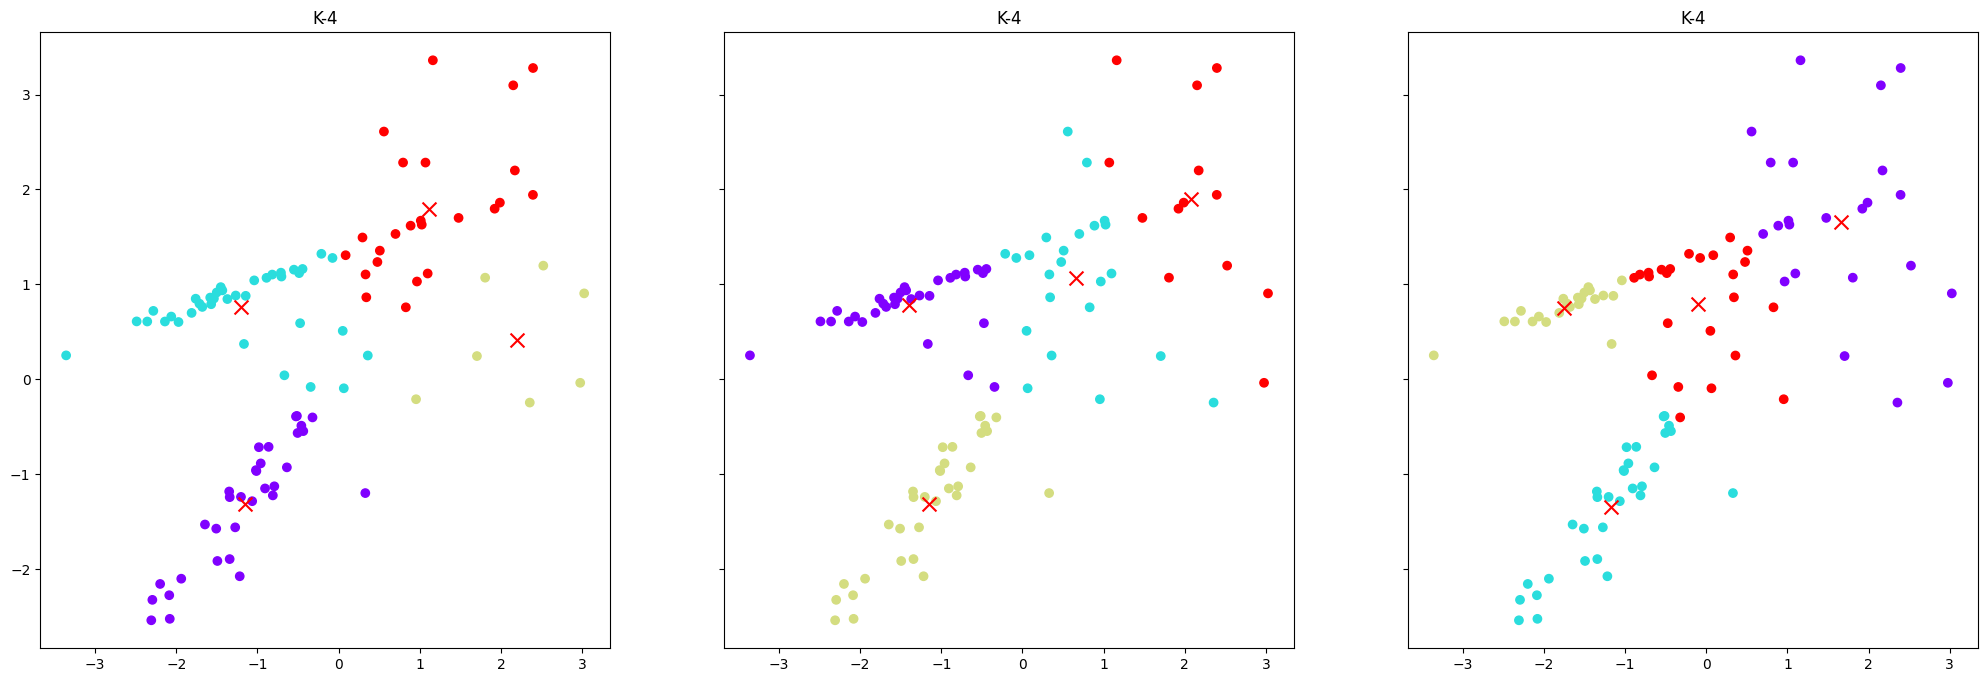

In [14]:
n = 3
f, ax = plt.subplots(1, n, sharey=True, figsize=(25,8))

data = make_classification(
    n_features = 2,
    n_redundant = 0,
    n_informative = 2,
    n_clusters_per_class = 1,
    n_classes = 3,
    random_state = 24
)

i = 0

for _ in range(n):
    ax[i].set_title('K-4'.format(4))
    kmeans = KMeans(n_clusters=4)
    kmeans.fit(data[0])

    ax[i].scatter(data[0][:,0], data[0][:,1], c = kmeans.labels_, cmap = 'rainbow')
    ax[i].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker = 'x', color = 'red', s = 100)
    i += 1


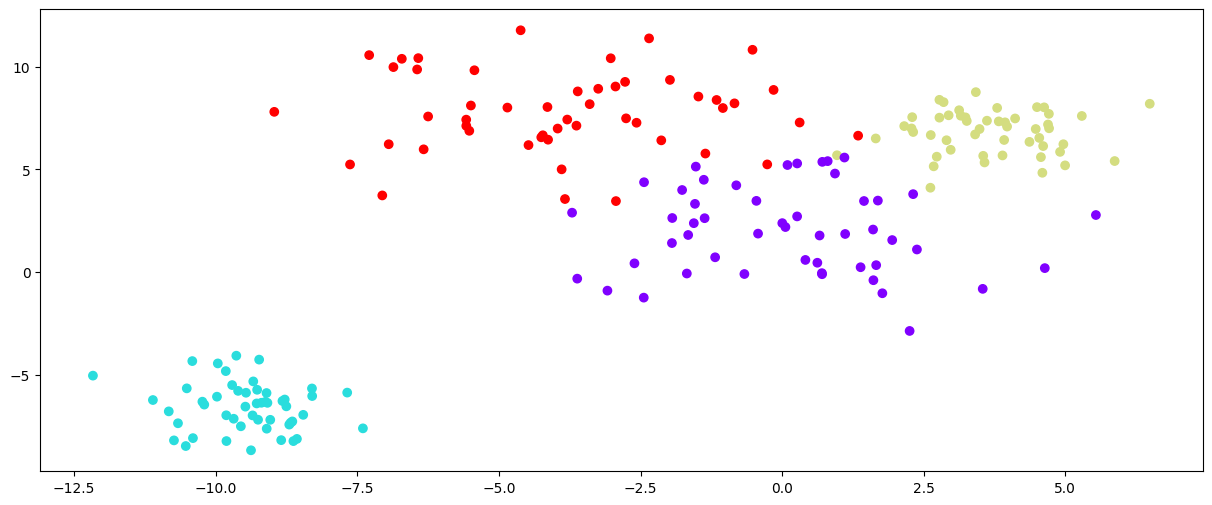

In [15]:
## Como encontrar um valor de K ideal ?

'''Método Elbow - Elbow Method'''

data = make_blobs(
    n_samples= 200,
    n_features= 2,
    centers=4,
    cluster_std=[2,1,1,2],
    random_state=101
)
fig, ax = plt.subplots(figsize=(15,6))
plt.scatter(
    data[0][:,0],
    data[0][:,1],
    c= data[1],
    cmap= 'rainbow',
)

In [16]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(data[0])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)",

In [17]:
kmeans.inertia_

994.4275403201597

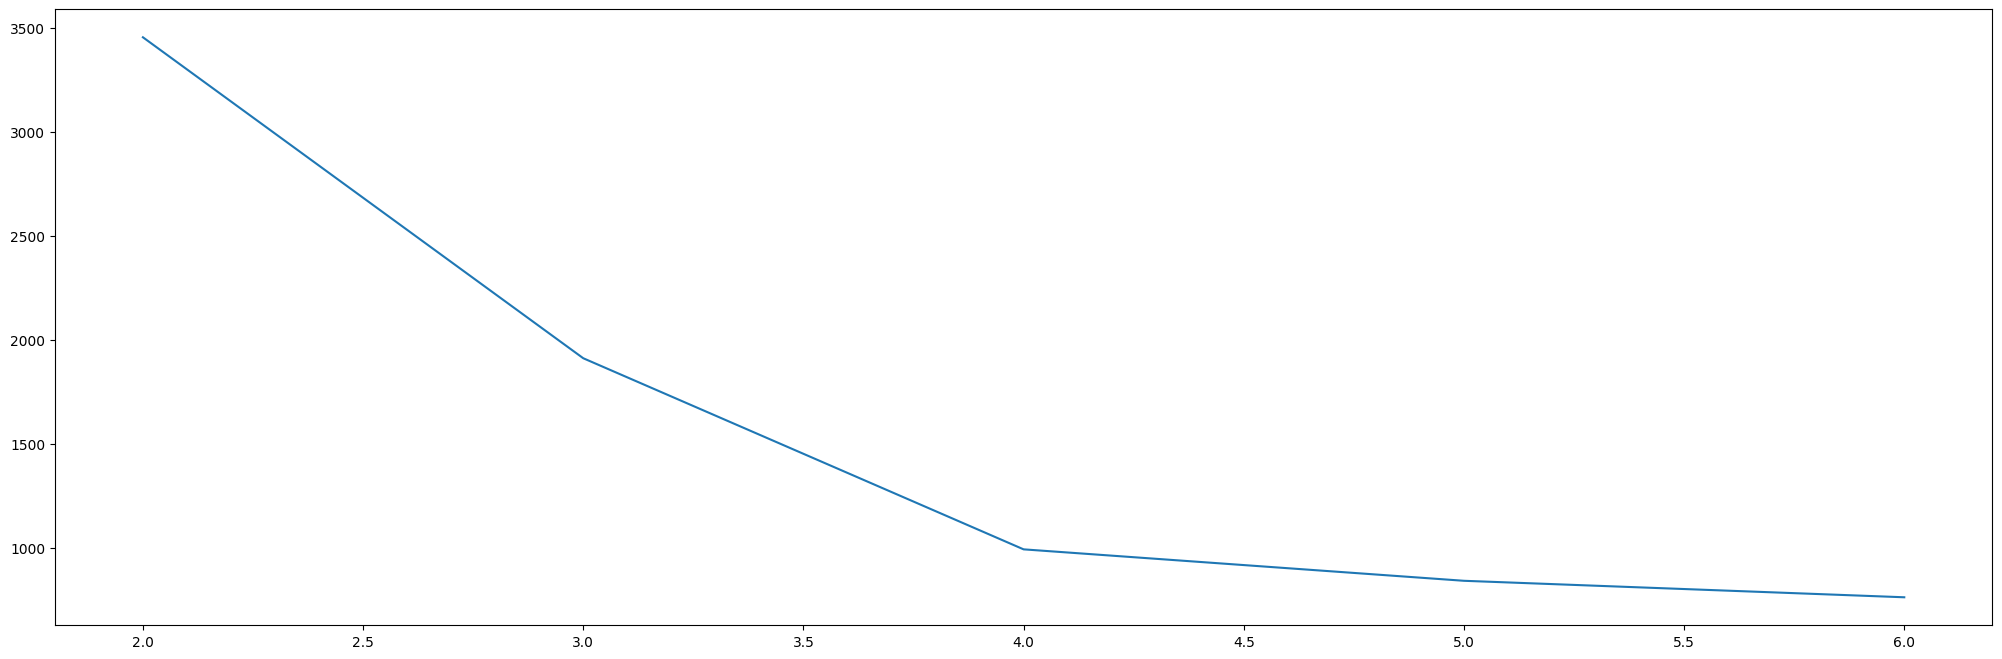

In [21]:
f, ax = plt.subplots(figsize=(25,8))
list_inertia = []
list_k = []

for k in [2,3,4,5,6]:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data[0])

    list_inertia += [kmeans.inertia_]
    list_k += [k]

ax.plot(list_k, list_inertia)    

## Mixture Models

Os Mixture Models (Modelos de Mistura) são algoritmos de aprendizado de máquina não supervisionado (Unsupervised Learning) usados para identificar grupos (clusters) em um conjunto de dados, assim como o K-Means. A principal diferença é que eles utilizam uma abordagem probabilística, permitindo representar grupos com formatos mais complexos e atribuir a cada observação uma probabilidade de pertencer a cada cluster.

Em vez de dizer que um dado pertence apenas a um grupo, o Mixture Model responde:

"Este ponto tem 85% de chance de pertencer ao Grupo A e 15% ao Grupo B."

Essa característica o torna mais flexível para dados reais, onde as fronteiras entre grupos nem sempre são bem definidas.

O que significa "Mixture Model"?

A ideia central é que os dados observados são gerados pela mistura de várias distribuições estatísticas.

Imagine uma turma de alunos em que existem três perfis:

Estudantes iniciantes;
Estudantes intermediários;
Estudantes avançados.

As notas finais podem ser vistas como uma mistura dessas três populações. O algoritmo tenta descobrir automaticamente quais distribuições geraram os dados.

### Exemplo de Mixture Models

In [22]:
'''A premissa do GMM é que cada grupo de dados pode ser aproximado por uma distribuição normal (uma “nuvem” em formato elíptico).

Não é o conjunto inteiro dos dados que precisa ser normal, mas sim cada cluster individualmente.

Antes de rodar o algoritmo, não dá para ter certeza disso, porque você ainda não sabe quais são os grupos. O que pode ser feito é uma análise visual para verificar se os dados parecem formar nuvens mais “ovais” do que formatos muito irregulares.

Na prática, você testa o GMM, observa o resultado e compara com outros métodos para ver se o ajuste faz sentido.'''

from sklearn.datasets import make_gaussian_quantiles

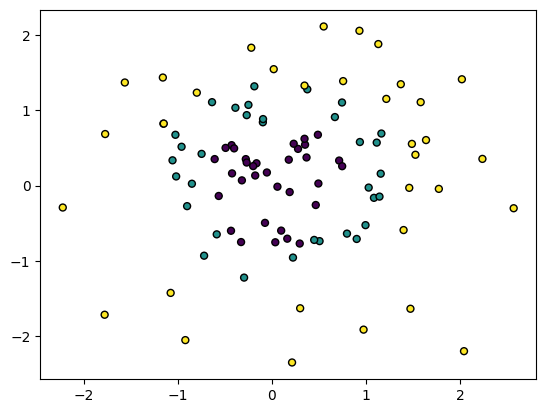

In [23]:
x1, y1 = make_gaussian_quantiles(
    n_features= 2,
    n_classes= 3
)

plt.scatter(
    x1[:,0],
    x1[:,1],
    marker='o',
    c= y1,
    s= 25,
    edgecolors= 'k'
)